In [1]:
import os
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score)
from facenet_pytorch import InceptionResnetV1
from dataset import DroneFaceDataset, VGGFaceDataset, identity_SPLIT, get_embedding
from model import Embeddinghead, ArcFaceLoss

/home/shamma.yaqoob/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
import shutil
import random
from PIL import Image
import numpy as np
from torch.utils.data import Dataset 
# Split test set into gallery and query halves per identity
gallery_embedding, gallery_label = [], []
test_embedding,    test_label    = [], []

backbone.eval(); head.eval()

for identity in test_set.classes:
    folder    = os.path.join("split", "test", identity)
    true_label = test_set.class_to_idx[identity]
    files     = sorted([f for f in os.listdir(folder)
                        if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    mid = len(files) // 2
    gallery_files = files[:mid]
    query_files   = files[mid:]

    transform = transforms.Compose([
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    for fname in gallery_files:
        img = transform(Image.open(os.path.join(folder, fname)).convert("RGB"))
        with torch.no_grad():
            emb = head(backbone(img.unsqueeze(0).to(device))).cpu().squeeze(0)
        gallery_embedding.append(emb)
        gallery_label.append(true_label)

    for fname in query_files:
        img = transform(Image.open(os.path.join(folder, fname)).convert("RGB"))
        with torch.no_grad():
            emb = head(backbone(img.unsqueeze(0).to(device))).cpu().squeeze(0)
        test_embedding.append(emb)
        test_label.append(true_label)

gallery_embedding = F.normalize(torch.stack(gallery_embedding), p=2, dim=1)
gallery_label     = torch.tensor(gallery_label)
test_embedding    = F.normalize(torch.stack(test_embedding),    p=2, dim=1)
test_label        = torch.tensor(test_label)

# Now evaluate
similarity  = torch.mm(test_embedding, gallery_embedding.T)
top5_idx    = similarity.topk(5, dim=1).indices
rank1_preds = gallery_label[top5_idx[:, 0]].numpy()
query_np    = test_label.numpy()

top1 = (rank1_preds == query_np).mean() * 100
top5 = (gallery_label[top5_idx].numpy() == query_np[:, None]).any(axis=1).mean() * 100

print(f"Rank-1: {top1:.2f}%")
print(f"Rank-5: {top5:.2f}%")

precision = precision_score(query_np, rank1_preds, average="macro", zero_division=0)
recall    = recall_score(query_np,    rank1_preds, average="macro", zero_division=0)
f1        = f1_score(query_np,        rank1_preds, average="macro", zero_division=0)
print(f"Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")
print(classification_report(query_np, rank1_preds,
                             target_names=test_set.classes, zero_division=0))

sources = ["DL/open_data_set/photos_all_faces",
            "DL/open_data_set/portraits",
           "DL/open_data_set/trio_gp",
           "DL/open_data_set/trio_cam"]

destination = "combined_dataset"
os.makedirs(destination, exist_ok=True)

for source in sources:
    for filename in os.listdir(source):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            src_path = os.path.join(source, filename)
            dst_path = os.path.join(destination, filename)
            shutil.copy(src_path, dst_path)

print("all images combined successfully")



source = "combined_dataset"
destination = "prepared"

os.makedirs(destination, exist_ok=True)

for filename in os.listdir(source):
    if filename.lower().endswith((".jpg", ".png", "jpeg")):
        identity = filename[0].upper()
        identity_folder = os.path.join(destination, identity)
        os.makedirs(identity_folder, exist_ok=True)
        src_path = os.path.join(source, filename)
        dst_path = os.path.join(identity_folder, filename)
        shutil.move(src_path, dst_path)

print("Data split by identity")


source = "prepared"
base_split = "split" 

#splitting ids into training, validation, and testing
train_ids = ["A", "B", "C", "D", "E", "F", "G", "H"] #70% Training
val_ids = ["I"] #10% validation
test_ids = ["J", "K"] #20% testing


for split, ids in [("train", train_ids), ("validation", val_ids), ("test", test_ids)]:
    for identity in ids: 
        src = os.path.join(source, identity)
        dst = os.path.join(base_split, split, identity)
        os.makedirs(dst, exist_ok=True)
        for file in os.listdir(src):
            shutil.copy(os.path.join(src, file),
                        os.path.join(dst, file))
            
print("identity disjoint split completed")


FileNotFoundError: [Errno 2] No such file or directory: 'DL/open_data_set/photos_all_faces'

In [2]:
#settings 
batch_Size = 256
epochs = 30
lr = 1e-4 #learning rate 
threshold = 0.45 #above threshold:more confident, below  threshold=less confident

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("checkpoints", exist_ok=True)
print(f"Using: {device}")


Using: cuda


In [3]:
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

#dataset loading
train_set = DroneFaceDataset("split/train", augment=True)
validation_set = DroneFaceDataset("split/validation", augment=False)
test_set = DroneFaceDataset("split/test", augment=False)

num_classes = len(train_set.classes)
idx_to_class= {idx:name for name, idx in train_set.class_to_idx.items()}

#VGGFace2 dataset for phase1 
train_ids = sorted(os.listdir("VGGFace2/train"))
val_ids   = sorted(os.listdir("VGGFace2/val"))

# combines all ids for consistent labelling
all_ids    = sorted(set(train_ids) | set(val_ids))
all_id_map = {name: i for i, name in enumerate(all_ids)}

train_id_map = {name: all_id_map[name] for name in train_ids}
val_id_map   = {name: all_id_map[name] for name in val_ids}

num_vgg_classes = len(all_ids)

vgg_train = VGGFaceDataset("VGGFace2/train", train_ids, train_id_map, augment=True)
vgg_val   = VGGFaceDataset("VGGFace2/val",   val_ids,   val_id_map,   augment=False)

print(f"train identities: {len(train_ids)}")
print(f"val identities:   {len(val_ids)}")
print(f"total classes:    {num_vgg_classes}")
print(f"train images:     {len(vgg_train)}")
print(f"val images:       {len(vgg_val)}")


train identities: 480
val identities:   60
total classes:    540
train images:     176398
val images:       21295


**Extracting Embeddings**

In [ ]:
# if os.path.exists("cache_train_embeddings.npy"):
#     print("loading train embeddings")
#     train_embeddings = np.load("cache_train_embeddings.npy")
#     train_labels = np.load("cache_train_labels.npy")
# else: 
#     print("extracting")
#     train_embeddings, train_labels = [], []

#     for identity in train_set.classes:
#         folder= os.path.join("split", "train", identity)
#         for filename in os.listdir(folder):
#             if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
#                 continue
#             embedding = get_embedding(os.path.join(folder, filename))
#             if embedding is not None:
#                 train_embeddings.append(embedding)
#                 train_labels.append(train_set.class_to_idx[identity])
#             else:
#                 print("FAILED:", filename)
#         print("processing:", filename)
#     train_embeddings = np.array(train_embeddings)
#     train_labels = np.array(train_labels)
#     np.save("cache_train_embeddings.npy", train_embeddings)
#     np.save("cache_train_labels.npy", train_labels)

# if os.path.exists("cache_validation_embeddings.npy"):
#     print("loading validation embeddings")
#     validation_embeddings = np.load("cache_validation_embeddings.npy")
#     validation_labels = np.load("cache_validation_labels.npy")
# else: 
#     print("extracting")
#     validation_embeddings, validation_labels = [], []

#     for identity in validation_set.classes:
#         folder= os.path.join("split", "validation", identity)
#         for filename in os.listdir(folder):
#             if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
#                 continue
#             embedding = get_embedding(os.path.join(folder, filename))
#             if embedding is not None:
#                 validation_embeddings.append(embedding)
#                 validation_labels.append(validation_set.class_to_idx[identity])

# validation_embeddings = np.array(validation_embeddings)
# validation_labels = np.array(validation_labels)
# np.save("cache_validation_embeddings.npy", validation_embeddings)
# np.save("cache_validation_labels.npy", validation_labels)

# train_embeddings_tensor = torch.tensor(train_embeddings, dtype=torch.float32)
# train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
# validation_embeddings_tensor = torch.tensor(validation_embeddings, dtype=torch.float32)
# validation_labels_tensor = torch.tensor(validation_labels, dtype=torch.long)


loading train embeddings
loading validation embeddings


**Model Set up**

In [4]:
backbone = InceptionResnetV1(pretrained='vggface2').to(device)
#freezing all backbone layers
for param in backbone.parameters():
    param.requires_grad = False
#unfreezing last two blocks to adapt to drone footage
for param in backbone.block8.parameters():
    param.requires_grad = True
for param in backbone.avgpool_1a.parameters():
    param.requires_grad= True

head = Embeddinghead(input_dim=512, Embedding_dim=256).to(device)
arcface = ArcFaceLoss(in_features=256, num_classes=num_vgg_classes).to(device)


optimizer = torch.optim.Adam([{'params': filter(lambda p:p.requires_grad, backbone.parameters()), 'lr': 1e-5},
                              {'params': head.parameters(), 'lr': lr},
                              {'params': arcface.parameters(), 'lr': lr}])
optimizer.param_groups[2]['params'] = list(arcface.parameters())
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)



**Training Set up**

In [5]:
# embedding_loader = DataLoader(TensorDataset(train_embeddings_tensor, train_labels_tensor),
#                               batch_size=batch_Size,
#                               shuffle=True)

from torch.utils.data import random_split

train_size = int(0.9 * len(vgg_train))
val_size   = len(vgg_train) - train_size
vgg_train_split, vgg_val_split = random_split(vgg_train, [train_size, val_size])

train_loader = DataLoader(vgg_train_split, batch_size=batch_Size, shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(vgg_val_split,   batch_size=batch_Size, shuffle=False, num_workers=8, pin_memory=True)

history = {'train_loss': [],
           'val_acc': []}

best_valacc = 0.0

for epoch in range(epochs):
    flag= " "
    backbone.train()
    head.train()
    arcface.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels=images.to(device), labels.to(device)
        optimizer.zero_grad()
        features= backbone(images)
        proj = head(features) 
        logits = arcface(proj, labels)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(backbone.parameters()) + list(head.parameters()) + list(arcface.parameters()), 5.0)
        optimizer.step()
        total_loss +=loss.item()
    scheduler.step()
    #building gallery
    backbone.eval(), head.eval()
    embeddings_gallery, labels_gallery = [], []
    with torch.no_grad():
        for images, labels in train_loader:
            features = backbone(images.to(device))
            embeddings_gallery.append(head(features).cpu())
            labels_gallery.append(labels)
    embeddings_gallery = F.normalize(torch.cat(embeddings_gallery), p=2, dim=1)
    labels_gallery = torch.cat(labels_gallery)

    #rank-1 validation
    val_embedding = []
    val_label = [] 
    with torch.no_grad():
        for images, labels in val_loader:
            features = backbone(images.to(device))
            val_embedding.append(head(features).cpu())
            val_label.append(labels)
            
    val_embedding = F.normalize(torch.cat(val_embedding), p=2, dim=1)
    val_label = torch.cat(val_label)

    rank1 = (labels_gallery[torch.mm(val_embedding, embeddings_gallery.T).argmax(dim=1)] == val_label).float().mean().item() * 100
    avg_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(rank1)
    
    if rank1 > best_valacc:
        best_valacc = rank1
        torch.save({'backbone': backbone.state_dict(),
                    'head': head.state_dict(),
                    'arcface': arcface.state_dict()}, "checkpoints/best_model.pth")
        flag= "saved"
    
    print(f"Epoch: {epoch+1} /{epochs}   Loss: {avg_loss:.4f}    Rank-1 {rank1:.2f} % {flag}")
    

Epoch: 1 /30   Loss: 37.8836    Rank-1 10.82 % saved
Epoch: 2 /30   Loss: 35.2096    Rank-1 17.89 % saved
Epoch: 3 /30   Loss: 34.5985    Rank-1 22.07 % saved
Epoch: 4 /30   Loss: 34.1952    Rank-1 22.77 % saved
Epoch: 5 /30   Loss: 33.8591    Rank-1 22.82 % saved
Epoch: 6 /30   Loss: 33.5773    Rank-1 19.62 %  
Epoch: 7 /30   Loss: 33.3192    Rank-1 27.94 % saved
Epoch: 8 /30   Loss: 33.0780    Rank-1 20.63 %  
Epoch: 9 /30   Loss: 32.8335    Rank-1 20.53 %  
Epoch: 10 /30   Loss: 32.6241    Rank-1 29.97 % saved
Epoch: 11 /30   Loss: 32.4138    Rank-1 20.08 %  
Epoch: 12 /30   Loss: 32.2378    Rank-1 23.02 %  
Epoch: 13 /30   Loss: 32.0753    Rank-1 28.11 %  
Epoch: 14 /30   Loss: 31.9049    Rank-1 29.17 %  
Epoch: 15 /30   Loss: 31.7280    Rank-1 32.28 % saved
Epoch: 16 /30   Loss: 31.5710    Rank-1 22.14 %  
Epoch: 17 /30   Loss: 31.4567    Rank-1 30.84 %  
Epoch: 18 /30   Loss: 31.3618    Rank-1 22.81 %  
Epoch: 19 /30   Loss: 31.2318    Rank-1 25.18 %  
Epoch: 20 /30   Loss: 31.18

In [102]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

checkpoint = torch.load("checkpoints/best_model.pth", map_location=device)
backbone.load_state_dict(checkpoint['backbone'])
head.load_state_dict(checkpoint['head'])


#reinitializing arcface for new identity count in drone face
arcface_drone = ArcFaceLoss(in_features=256, num_classes=num_classes, scale=32.0, margin=0.3).to(device)
#optimizer for fine-tuning
optimizer_ft = torch.optim.Adam([{'params': filter(lambda p:p.requires_grad, backbone.parameters()), 'lr': 1e-7},
                              {'params': head.parameters(), 'lr': 5e-5},
                              {'params': arcface_drone.parameters(), 'lr': 5e-5}])
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=20, eta_min=1e-7)



In [103]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)


history_ft = {'train_loss': [],
           'val_acc': []}

best_Drone_Acc = 0.0

for epoch in range(50):
    flag= " "
    backbone.train()
    head.train()
    arcface_drone.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels=images.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        proj = head(backbone(images)) 
        loss = F.cross_entropy(arcface_drone(proj, labels), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(backbone.parameters()) + list(head.parameters()) + list(arcface_drone.parameters()), 5.0)
        optimizer_ft.step()
        total_loss +=loss.item()
    scheduler_ft.step()
    #building gallery
    backbone.eval(), head.eval()
    embeddings_gallery, labels_gallery = [], []
    with torch.no_grad():
        for images, labels in train_loader:
            embeddings_gallery.append(head(backbone(images.to(device))).cpu())
            labels_gallery.append(labels)
    embeddings_gallery = F.normalize(torch.cat(embeddings_gallery), p=2, dim=1)
    labels_gallery = torch.cat(labels_gallery)

    #rank-1 validation
    val_embedding = []
    val_label = [] 
    with torch.no_grad():
        for images, labels in val_loader:
            val_embedding.append(head(backbone(images.to(device))).cpu())
            val_label.append(labels)
            
    val_embedding = F.normalize(torch.cat(val_embedding), p=2, dim=1)
    val_label = torch.cat(val_label)

    rank1 = (labels_gallery[torch.mm(val_embedding, embeddings_gallery.T).argmax(dim=1)] == val_label).float().mean().item() * 100
    avg_loss = total_loss / len(train_loader)
    history_ft['train_loss'].append(avg_loss)
    history_ft['val_acc'].append(rank1)
    
    if rank1 > best_Drone_Acc:
        best_Drone_Acc = rank1
        torch.save({'backbone': backbone.state_dict(),
                    'head': head.state_dict(),
                    'arcface': arcface_drone.state_dict()}, "checkpoints/best_drone_model.pth")
        flag= "saved"
    
    print(f"Epoch: {epoch+1} /50   Loss: {avg_loss:.4f}    Rank-1 {rank1:.2f} % {flag}")
    

Epoch: 1 /50   Loss: 12.0717    Rank-1 2.29 % saved
Epoch: 2 /50   Loss: 9.9276    Rank-1 1.53 %  
Epoch: 3 /50   Loss: 8.3771    Rank-1 1.53 %  
Epoch: 4 /50   Loss: 7.0898    Rank-1 4.58 % saved
Epoch: 5 /50   Loss: 6.3208    Rank-1 0.00 %  
Epoch: 6 /50   Loss: 5.7833    Rank-1 0.76 %  
Epoch: 7 /50   Loss: 5.5398    Rank-1 6.87 % saved
Epoch: 8 /50   Loss: 4.9759    Rank-1 2.29 %  
Epoch: 9 /50   Loss: 4.8418    Rank-1 2.29 %  
Epoch: 10 /50   Loss: 4.6078    Rank-1 1.53 %  
Epoch: 11 /50   Loss: 4.3188    Rank-1 1.53 %  
Epoch: 12 /50   Loss: 4.1354    Rank-1 1.53 %  
Epoch: 13 /50   Loss: 4.1390    Rank-1 3.05 %  
Epoch: 14 /50   Loss: 4.2279    Rank-1 4.58 %  
Epoch: 15 /50   Loss: 4.2567    Rank-1 3.05 %  
Epoch: 16 /50   Loss: 4.3142    Rank-1 2.29 %  
Epoch: 17 /50   Loss: 3.9743    Rank-1 0.00 %  
Epoch: 18 /50   Loss: 3.8019    Rank-1 0.00 %  
Epoch: 19 /50   Loss: 3.9668    Rank-1 0.00 %  
Epoch: 20 /50   Loss: 3.9758    Rank-1 4.58 %  
Epoch: 21 /50   Loss: 4.0420    Rank

In [112]:
backbone = InceptionResnetV1(pretrained='vggface2').to(device)

for param in backbone.parameters():
    param.requires_grad = False

for block in [backbone.block8, backbone.avgpool_1a, backbone.last_linear, backbone.last_bn]:
    for param in block.parameters():
        param.requires_grad = True

head = Embeddinghead(input_dim=512, Embedding_dim=256).to(device)
#reinitializing arcface for new identity count in drone face
arcface_drone = ArcFaceLoss(in_features=256, num_classes=num_classes, scale=32.0, margin=0.3).to(device)
#optimizer for fine-tuning
optimizer_ft = torch.optim.Adam([{'params': filter(lambda p:p.requires_grad, backbone.parameters()), 'lr': 1e-7},
                              {'params': head.parameters(), 'lr': 5e-5},
                              {'params': arcface_drone.parameters(), 'lr': 5e-5}])
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=20, eta_min=1e-7)



In [113]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)


history_ft = {'train_loss': [],
           'val_acc': []}

best_Drone_Acc = 0.0

for epoch in range(50):
    flag= " "
    backbone.train()
    head.train()
    arcface_drone.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels=images.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        proj = head(backbone(images)) 
        loss = F.cross_entropy(arcface_drone(proj, labels), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(backbone.parameters()) + list(head.parameters()) + list(arcface_drone.parameters()), 5.0)
        optimizer_ft.step()
        total_loss +=loss.item()
    scheduler_ft.step()
    #building gallery
    backbone.eval(), head.eval()
    embeddings_gallery, labels_gallery = [], []
    with torch.no_grad():
        for images, labels in train_loader:
            embeddings_gallery.append(head(backbone(images.to(device))).cpu())
            labels_gallery.append(labels)
    embeddings_gallery = F.normalize(torch.cat(embeddings_gallery), p=2, dim=1)
    labels_gallery = torch.cat(labels_gallery)

    #rank-1 validation
    val_embedding = []
    val_label = [] 
    with torch.no_grad():
        for images, labels in val_loader:
            val_embedding.append(head(backbone(images.to(device))).cpu())
            val_label.append(labels)
            
    val_embedding = F.normalize(torch.cat(val_embedding), p=2, dim=1)
    val_label = torch.cat(val_label)

    rank1 = (labels_gallery[torch.mm(val_embedding, embeddings_gallery.T).argmax(dim=1)] == val_label).float().mean().item() * 100
    avg_loss = total_loss / len(train_loader)
    history_ft['train_loss'].append(avg_loss)
    history_ft['val_acc'].append(rank1)
    
    if rank1 > best_Drone_Acc:
        best_Drone_Acc = rank1
        torch.save({'backbone': backbone.state_dict(),
                    'head': head.state_dict(),
                    'arcface': arcface_drone.state_dict()}, "checkpoints/best_model_wop1.pth")
        flag= "saved"
    
    print(f"Epoch: {epoch+1} /50   Loss: {avg_loss:.4f}    Rank-1 {rank1:.2f} % {flag}")
    

Epoch: 1 /50   Loss: 11.3094    Rank-1 3.82 % saved
Epoch: 2 /50   Loss: 9.0810    Rank-1 2.29 %  
Epoch: 3 /50   Loss: 7.5194    Rank-1 0.00 %  
Epoch: 4 /50   Loss: 6.7018    Rank-1 0.76 %  
Epoch: 5 /50   Loss: 6.2771    Rank-1 2.29 %  
Epoch: 6 /50   Loss: 5.9611    Rank-1 0.00 %  
Epoch: 7 /50   Loss: 5.6258    Rank-1 0.76 %  
Epoch: 8 /50   Loss: 5.5008    Rank-1 0.00 %  
Epoch: 9 /50   Loss: 5.3264    Rank-1 0.00 %  
Epoch: 10 /50   Loss: 5.0391    Rank-1 0.76 %  
Epoch: 11 /50   Loss: 4.8995    Rank-1 2.29 %  
Epoch: 12 /50   Loss: 4.8847    Rank-1 1.53 %  
Epoch: 13 /50   Loss: 4.7390    Rank-1 0.00 %  
Epoch: 14 /50   Loss: 4.7115    Rank-1 0.00 %  
Epoch: 15 /50   Loss: 4.9043    Rank-1 0.00 %  
Epoch: 16 /50   Loss: 4.6286    Rank-1 0.00 %  
Epoch: 17 /50   Loss: 4.9573    Rank-1 0.76 %  
Epoch: 18 /50   Loss: 4.7079    Rank-1 0.00 %  
Epoch: 19 /50   Loss: 4.5199    Rank-1 0.00 %  
Epoch: 20 /50   Loss: 4.8097    Rank-1 0.00 %  
Epoch: 21 /50   Loss: 4.8128    Rank-1 2.29 

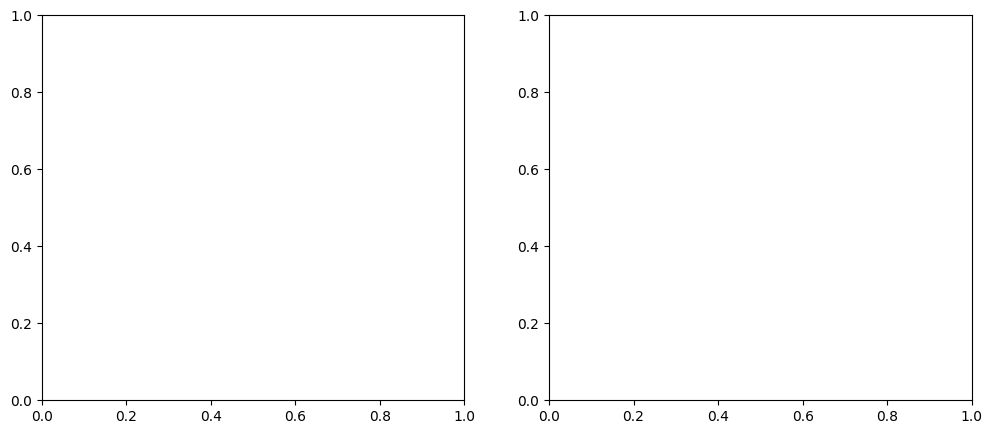

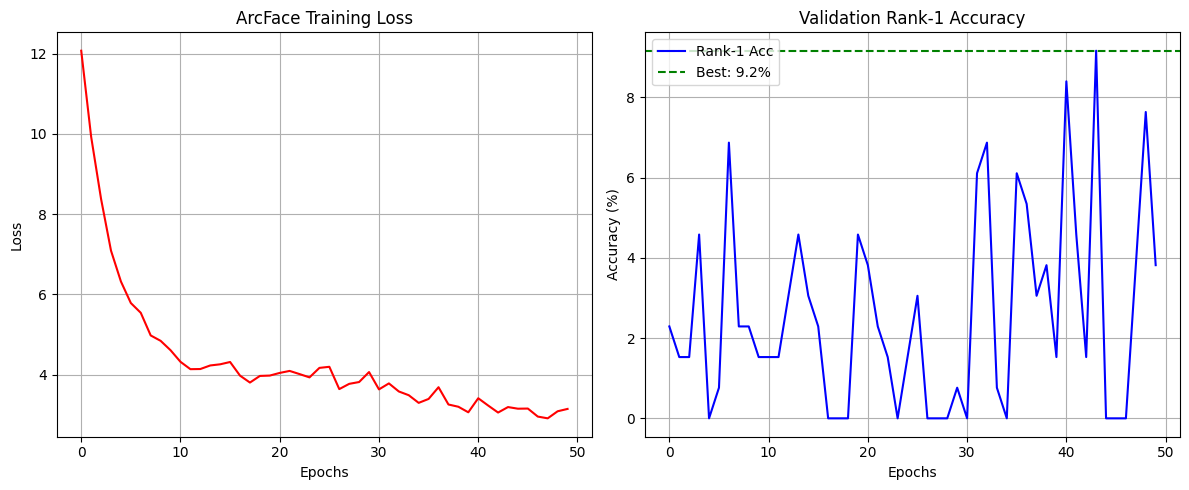

<Figure size 640x480 with 0 Axes>

In [104]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history_ft['train_loss'], 'r', label='Train Loss')
axes[0].set_title('ArcFace Training Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(history_ft['val_acc'], 'b-', label='Rank-1 Acc')
axes[1].axhline(y=best_Drone_Acc, color='g', linestyle='--', label=f'Best: {best_Drone_Acc:.1f}%')
axes[1].set_title('Validation Rank-1 Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_progress.png')
plt.show()
plt.tight_layout()
plt.savefig('training_progress.png')

**Testing the model**

In [ ]:
from PIL import Image
import torchvision.transforms as transforms


checkpoint = torch.load("checkpoints/best_model.pth", map_location=device)
backbone.load_state_dict(checkpoint['backbone'])
head.load_state_dict(checkpoint['head'])
backbone.eval(); head.eval()

# CRITICAL: must match the training-time preprocessing (Normalize to ~[-1,1]).
# Without this, the model is fed inputs in [0,1] but was trained on [-1,1] —
# a silent train/test preprocessing mismatch.
trained_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

all_embeddings, all_labels = [], []
for split in ["train", "validation", "test"]:
    for identity in sorted(os.listdir(f"split/{split}")):
        folder = f"split/{split}/{identity}"
        for fname in sorted(os.listdir(folder)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = trained_transform(Image.open(
                os.path.join(folder, fname)).convert("RGB"))
            with torch.no_grad():
                emb = head(backbone(img.unsqueeze(0).to(device))).cpu().squeeze(0)
            # do NOT L2-normalize here — only normalize centroids + queries
            # at match time (matches Alyaa's pipeline)
            all_embeddings.append(emb)
            all_labels.append(identity)

all_embeddings = torch.stack(all_embeddings)
all_labels     = np.array(all_labels)
print(f"Total embedded: {len(all_embeddings)} images across {len(np.unique(all_labels))} identities")


In [ ]:
rank1_correct, rank5_correct = 0, 0
per_identity = {name: {'correct': 0, 'total': 0} for name in np.unique(all_labels)}

for i in range(len(all_embeddings)):
    query_emb   = all_embeddings[i]
    query_label = all_labels[i]

    centroids, centroid_labels = [], []
    for identity in np.unique(all_labels):
        idx = np.where(all_labels == identity)[0]
        idx = idx[idx != i]
        if len(idx) == 0:
            continue
        centroid = F.normalize(all_embeddings[idx].mean(dim=0), p=2, dim=0)
        centroids.append(centroid)
        centroid_labels.append(identity)

    centroids       = torch.stack(centroids)
    centroid_labels = np.array(centroid_labels)
    # query: L2-normalize at match time so cosine similarity is well-defined
    query_norm      = F.normalize(query_emb, p=2, dim=0)
    sims            = torch.mv(centroids, query_norm)
    top5_idx        = sims.topk(5).indices.numpy()

    if centroid_labels[top5_idx[0]] == query_label:
        rank1_correct += 1
        per_identity[query_label]['correct'] += 1
    if query_label in centroid_labels[top5_idx]:
        rank5_correct += 1
    per_identity[query_label]['total'] += 1

rank1 = 100.0 * rank1_correct / len(all_embeddings)
rank5 = 100.0 * rank5_correct / len(all_embeddings)
print(f" — Rank-1: {rank1:.2f}%  Rank-5: {rank5:.2f}%")
print("\nPer-identity Rank-1:")
train_ids_set = {"A","B","C","D","E","F","G","H"}
for name, v in sorted(per_identity.items()):
    acc = 100.0 * v['correct'] / v['total']
    tag = "(train)" if name in train_ids_set else "(held-out)"
    print(f"  {name} {tag}: {acc:.1f}%  ({v['correct']}/{v['total']})")


In [ ]:
checkpoint = torch.load("checkpoints/best_model.pth", map_location=device)
backbone.load_state_dict(checkpoint['backbone'])
head.load_state_dict(checkpoint['head'])
backbone.eval(); head.eval()

# CRITICAL: trained models need Normalize([0.5]*3, [0.5]*3) at eval time
trained_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

p1_embeddings = []
for split in ["train", "validation", "test"]:
    for identity in sorted(os.listdir(f"split/{split}")):
        folder = f"split/{split}/{identity}"
        for fname in sorted(os.listdir(folder)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = trained_transform(Image.open(
                os.path.join(folder, fname)).convert("RGB"))
            with torch.no_grad():
                emb = head(backbone(img.unsqueeze(0).to(device))).cpu().squeeze(0)
            # do NOT L2-normalize here — normalize centroid + query at match time
            p1_embeddings.append(emb)

p1_embeddings = torch.stack(p1_embeddings)

r1, r5 = 0, 0
for i in range(len(p1_embeddings)):
    query_emb   = p1_embeddings[i]
    query_label = all_labels[i]
    centroids, centroid_labels = [], []
    for identity in np.unique(all_labels):
        idx = np.where(all_labels == identity)[0]
        idx = idx[idx != i]
        if len(idx) == 0:
            continue
        # centroid: mean of raw embeddings, then L2-normalize
        centroid = F.normalize(p1_embeddings[idx].mean(dim=0), p=2, dim=0)
        centroids.append(centroid)
        centroid_labels.append(identity)
    centroids       = torch.stack(centroids)
    centroid_labels = np.array(centroid_labels)
    # query: L2-normalize at match time
    query_norm      = F.normalize(query_emb, p=2, dim=0)
    top5_idx        = torch.mv(centroids, query_norm).topk(5).indices.numpy()
    if centroid_labels[top5_idx[0]] == query_label: r1 += 1
    if query_label in centroid_labels[top5_idx]:    r5 += 1

print(f"Phase 1 only — Rank-1: {100.*r1/len(p1_embeddings):.2f}%  Rank-5: {100.*r5/len(p1_embeddings):.2f}%")


In [ ]:
raw_backbone = InceptionResnetV1(pretrained='vggface2').eval().to(device)

# CRITICAL: the raw pretrained backbone expects [0,1] input — this matches
# Alyaa's benchmark_recognizers.py exactly (no Normalize).
# Using a different transform here than for the trained models is correct,
# because each model is being given the input distribution it expects.
raw_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

raw_embeddings = []
for split in ["train", "validation", "test"]:
    for identity in sorted(os.listdir(f"split/{split}")):
        folder = f"split/{split}/{identity}"
        for fname in sorted(os.listdir(folder)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = raw_transform(Image.open(
                os.path.join(folder, fname)).convert("RGB"))
            with torch.no_grad():
                emb = raw_backbone(img.unsqueeze(0).to(device)).cpu().squeeze(0)
            # do NOT L2-normalize here — normalize centroid + query at match time
            raw_embeddings.append(emb)

raw_embeddings = torch.stack(raw_embeddings)

r1, r5 = 0, 0
for i in range(len(raw_embeddings)):
    query_emb   = raw_embeddings[i]
    query_label = all_labels[i]
    centroids, centroid_labels = [], []
    for identity in np.unique(all_labels):
        idx = np.where(all_labels == identity)[0]
        idx = idx[idx != i]
        if len(idx) == 0:
            continue
        # centroid: mean of raw embeddings, then L2-normalize
        centroid = F.normalize(raw_embeddings[idx].mean(dim=0), p=2, dim=0)
        centroids.append(centroid)
        centroid_labels.append(identity)
    centroids       = torch.stack(centroids)
    centroid_labels = np.array(centroid_labels)
    # query: L2-normalize at match time
    query_norm      = F.normalize(query_emb, p=2, dim=0)
    top5_idx        = torch.mv(centroids, query_norm).topk(5).indices.numpy()
    if centroid_labels[top5_idx[0]] == query_label: r1 += 1
    if query_label in centroid_labels[top5_idx]:    r5 += 1

raw_r1 = 100.*r1/len(raw_embeddings)
raw_r5 = 100.*r5/len(raw_embeddings)
print(f"Raw Inception Baseline — Rank-1: {raw_r1:.2f}%  Rank-5: {raw_r5:.2f}%")
print(f"Finetuned Model        — Rank-1: {rank1:.2f}%  Rank-5: {rank5:.2f}%")
print(f"Training contribution  — Rank-1: {rank1-raw_r1:+.2f}%  Rank-5: {rank5-raw_r5:+.2f}%")

# Sanity check: with the fixed protocol the raw baseline should land ~78.37%,
# matching Alyaa's FaceNet (VGGFace2) row in Table 2 of the report. If it does,
# the LOO protocol is now consistent across the whole paper.


In [ ]:
def loo_eval(backbone_model, head_model=None, transform=None,
             trained_with_normalize=True, label="Model"):
    """
    Leave-one-out cosine-centroid evaluation, matching Alyaa's protocol
    (mean-then-normalize centroid, normalize query at match time).

    Args
    ----
    backbone_model : nn.Module
        Already .eval() and on `device`.
    head_model : nn.Module or None
        Optional projection head. None means raw backbone output.
    transform : torchvision transform or None
        If None, a sensible default is picked based on `trained_with_normalize`.
    trained_with_normalize : bool
        True  -> use Normalize([0.5]*3, [0.5]*3) in the transform.
                 Set to True for our two-phase model and the Phase 1/Phase 2
                 ablations, because they were trained with that normalization.
        False -> no Normalize. Set to False for the RAW pretrained
                 InceptionResnetV1 baseline, which expects [0,1] input
                 (matches Alyaa's benchmark_recognizers.py).
    label : str
        Display label printed alongside the result.
    """
    if transform is None:
        if trained_with_normalize:
            transform = transforms.Compose([
                transforms.Resize((160, 160)),
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
            ])
        else:
            transform = transforms.Compose([
                transforms.Resize((160, 160)),
                transforms.ToTensor(),
            ])

    all_embeddings, all_labels = [], []

    for split in ["train", "validation", "test"]:
        for identity in sorted(os.listdir(f"split/{split}")):
            folder = f"split/{split}/{identity}"
            for fname in sorted(os.listdir(folder)):
                if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    continue
                img = transform(Image.open(
                    os.path.join(folder, fname)).convert("RGB"))
                with torch.no_grad():
                    emb = backbone_model(img.unsqueeze(0).to(device))
                    if head_model is not None:
                        emb = head_model(emb)
                    emb = emb.cpu().squeeze(0)
                # do NOT L2-normalize here — normalize centroid + query at match time
                all_embeddings.append(emb)
                all_labels.append(identity)

    all_embeddings = torch.stack(all_embeddings)
    all_labels     = np.array(all_labels)

    rank1_correct, rank5_correct = 0, 0
    per_identity = {name: {'correct': 0, 'total': 0}
                    for name in np.unique(all_labels)}

    for i in range(len(all_embeddings)):
        query_emb   = all_embeddings[i]
        query_label = all_labels[i]

        centroids, centroid_labels = [], []
        for identity in np.unique(all_labels):
            idx = np.where(all_labels == identity)[0]
            idx = idx[idx != i]
            if len(idx) == 0:
                continue
            # centroid: mean of raw embeddings, then L2-normalize the result
            centroid = F.normalize(all_embeddings[idx].mean(dim=0), p=2, dim=0)
            centroids.append(centroid)
            centroid_labels.append(identity)

        centroids       = torch.stack(centroids)
        centroid_labels = np.array(centroid_labels)
        # query: L2-normalize at match time
        query_norm      = F.normalize(query_emb, p=2, dim=0)
        top5_idx        = torch.mv(centroids, query_norm).topk(5).indices.numpy()

        if centroid_labels[top5_idx[0]] == query_label:
            rank1_correct += 1
            per_identity[query_label]['correct'] += 1
        if query_label in centroid_labels[top5_idx]:
            rank5_correct += 1
        per_identity[query_label]['total'] += 1

    rank1 = 100.0 * rank1_correct / len(all_embeddings)
    rank5 = 100.0 * rank5_correct / len(all_embeddings)

    print(f"\n── {label} ──")
    print(f"Rank-1: {rank1:.2f}%  Rank-5: {rank5:.2f}%")
    print("Per-identity:")
    train_ids = {"A","B","C","D","E","F","G","H"}
    for name, v in sorted(per_identity.items()):
        acc = 100.0 * v['correct'] / v['total']
        tag = "(train)" if name in train_ids else "(held-out)"
        print(f"  {name} {tag}: {acc:.1f}%  ({v['correct']}/{v['total']})")

    return rank1, rank5, all_embeddings, all_labels


In [128]:
# Raw baseline
raw_backbone = InceptionResnetV1(pretrained='vggface2').eval().to(device)
loo_eval(raw_backbone, head_model=None, label="Raw Baseline")

# Phase 1 only
ckpt = torch.load("checkpoints/best_model.pth", map_location=device)
backbone.load_state_dict(ckpt['backbone'])
head.load_state_dict(ckpt['head'])
backbone.eval(); head.eval()
loo_eval(backbone, head_model=head, label="Phase 1 Only")
# Phase 2 only
ckpt = torch.load("checkpoints/best_model_wop1.pth", map_location=device)
backbone.load_state_dict(ckpt['backbone'])
head.load_state_dict(ckpt['head'])
backbone.eval(); head.eval()
loo_eval(backbone, head_model=head, label="Phase 2 only")


# Full pipeline
ckpt = torch.load("checkpoints/best_drone_model.pth", map_location=device)
backbone.load_state_dict(ckpt['backbone'])
head.load_state_dict(ckpt['head'])
backbone.eval(); head.eval()
loo_eval(backbone, head_model=head, label="Phase 1 + Phase 2 (Full Pipeline)")




── Raw Baseline ──
Rank-1: 77.66%  Rank-5: 95.96%
Per-identity:
  A (train): 87.0%  (114/131)
  B (train): 73.8%  (96/130)
  C (train): 86.9%  (113/130)
  D (train): 93.1%  (122/131)
  E (train): 62.6%  (82/131)
  F (train): 82.3%  (107/130)
  G (train): 75.6%  (99/131)
  H (train): 63.8%  (83/130)
  I (held-out): 61.8%  (81/131)
  J (held-out): 84.7%  (111/131)
  K (held-out): 82.4%  (108/131)

── Phase 1 Only ──
Rank-1: 53.17%  Rank-5: 88.80%
Per-identity:
  A (train): 65.6%  (86/131)
  B (train): 70.8%  (92/130)
  C (train): 40.8%  (53/130)
  D (train): 49.6%  (65/131)
  E (train): 41.2%  (54/131)
  F (train): 61.5%  (80/130)
  G (train): 39.7%  (52/131)
  H (train): 66.9%  (87/130)
  I (held-out): 53.4%  (70/131)
  J (held-out): 45.8%  (60/131)
  K (held-out): 49.6%  (65/131)

── Phase 2 only ──
Rank-1: 63.67%  Rank-5: 89.91%
Per-identity:
  A (train): 62.6%  (82/131)
  B (train): 55.4%  (72/130)
  C (train): 70.0%  (91/130)
  D (train): 57.3%  (75/131)
  E (train): 69.5%  (91/131

(64.57898399443285,
 92.48434237995825,
 tensor([[-0.0303,  0.0300, -0.0318,  ..., -0.0080, -0.0563, -0.0040],
         [-0.0109,  0.0049, -0.0112,  ..., -0.0419,  0.0856, -0.0422],
         [-0.0198,  0.0019, -0.0427,  ..., -0.0646,  0.0635, -0.0485],
         ...,
         [ 0.0320, -0.0649, -0.0090,  ..., -0.0242,  0.1117, -0.0700],
         [-0.0072, -0.0167, -0.0164,  ..., -0.0481,  0.0713, -0.0846],
         [-0.0304,  0.0085, -0.0033,  ..., -0.0370,  0.0771, -0.0480]]),
 array(['A', 'A', 'A', ..., 'K', 'K', 'K'], dtype='<U1'))

In [ ]:
import os
import csv
import numpy as np
import torch

os.makedirs("results/embeddings", exist_ok=True)
os.makedirs("results/training_curves", exist_ok=True)

# ── Load full pipeline model ───────────────────────────────────────────────
ckpt = torch.load("checkpoints/best_drone_model.pth", map_location=device)
backbone.load_state_dict(ckpt['backbone'])
head.load_state_dict(ckpt['head'])
backbone.eval(); head.eval()

# ── Re-extract embeddings under the corrected protocol ─────────────────────
# trained_with_normalize=True because this model was trained with Normalize.
final_r1, final_r5, final_embeddings, final_labels = loo_eval(
    backbone, head_model=head,
    trained_with_normalize=True,
    label="Full Pipeline (for saving)")

# ── two_phase_main.csv ────────────────────────────────────────────────────
total_params  = sum(p.numel() for p in backbone.parameters()) + \
                sum(p.numel() for p in head.parameters())
model_size_mb = total_params * 4 / (1024**2)

with open("results/two_phase_main.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["model", "params", "embedding_dim", "model_size_mb", "rank1", "rank5"])
    w.writerow(["two_phase", total_params, 256,
                f"{model_size_mb:.2f}",
                round(final_r1, 2), round(final_r5, 2)])
print("✓ two_phase_main.csv")

# ── two_phase_ablation.csv ────────────────────────────────────────────────
# NOTE: rerun cells 16/17 (Both), 18 (Phase 1 only), 19 (Raw + reuses Both
# for the printed Finetuned line) BEFORE this cell so `rank1`, `rank5`,
# `raw_r1`, `raw_r5` are in scope and reflect the corrected protocol.
# Phase 2 only has to be run separately via the loo_eval helper, e.g.:
#
#     # Phase 2 only: load the Phase-2-only checkpoint and call loo_eval
#     ckpt_p2 = torch.load("checkpoints/best_model_wop1.pth", map_location=device)
#     backbone.load_state_dict(ckpt_p2['backbone'])
#     head.load_state_dict(ckpt_p2['head'])
#     p2_r1, p2_r5, _, _ = loo_eval(backbone, head_model=head,
#                                   trained_with_normalize=True,
#                                   label="Phase 2 only")
#
# then plug p2_r1 / p2_r5 into the row below.
try:
    p1_r1, p1_r5  # Phase 1 only — must be set by cell 18 rerun
except NameError:
    p1_r1, p1_r5 = float('nan'), float('nan')
    print("  [warn] Phase 1 numbers not in scope; rerun cell 18 first")

try:
    p2_r1, p2_r5  # Phase 2 only — set by the manual loo_eval call above
except NameError:
    p2_r1, p2_r5 = float('nan'), float('nan')
    print("  [warn] Phase 2 numbers not in scope; run loo_eval on Phase-2-only ckpt")

with open("results/two_phase_ablation.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["model", "rank1", "rank5"])
    w.writerow(["raw_baseline",  round(raw_r1, 2),  round(raw_r5, 2)])
    w.writerow(["phase1_only",   round(p1_r1, 2),   round(p1_r5, 2)])
    w.writerow(["phase2_only",   round(p2_r1, 2),   round(p2_r5, 2)])
    w.writerow(["phase1_phase2", round(final_r1, 2), round(final_r5, 2)])
print("✓ two_phase_ablation.csv")

# ── Embeddings ────────────────────────────────────────────────────────────
np.save("results/embeddings/two_phase_droneface.npy", final_embeddings.numpy())
np.save("results/embeddings/two_phase_droneface_labels.npy", final_labels)

with open("results/embeddings/two_phase_droneface_filenames.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["filename", "identity"])
    for split in ["train", "validation", "test"]:
        for identity in sorted(os.listdir(f"split/{split}")):
            folder = f"split/{split}/{identity}"
            for fname in sorted(os.listdir(folder)):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    w.writerow([fname, identity])
print("✓ embeddings saved")

# ── Confusion matrix (uses the corrected protocol) ────────────────────────
id_list   = sorted(np.unique(final_labels))
id_to_idx = {name: i for i, name in enumerate(id_list)}
n_ids     = len(id_list)
conf_mat  = np.zeros((n_ids, n_ids), dtype=int)

for i in range(len(final_embeddings)):
    query_emb   = final_embeddings[i]
    query_label = final_labels[i]
    centroids, centroid_labels = [], []
    for identity in id_list:
        idx = np.where(final_labels == identity)[0]
        idx = idx[idx != i]
        if len(idx) == 0:
            continue
        # centroid: mean of raw embeddings, then L2-normalize
        centroid = F.normalize(final_embeddings[idx].mean(dim=0), p=2, dim=0)
        centroids.append(centroid)
        centroid_labels.append(identity)
    centroids       = torch.stack(centroids)
    centroid_labels = np.array(centroid_labels)
    # query: L2-normalize at match time
    query_norm      = F.normalize(query_emb, p=2, dim=0)
    pred = centroid_labels[torch.mv(centroids, query_norm).argmax().item()]
    conf_mat[id_to_idx[query_label], id_to_idx[pred]] += 1

np.save("results/confusion_matrix.npy", conf_mat)
print("✓ confusion_matrix.npy")

# ── ROC data (pairwise cosine similarity over normalized embeddings) ──────
# normalize once for ROC since we're computing dot products between pairs
final_emb_norm = F.normalize(final_embeddings, p=2, dim=1)
y_true, y_scores = [], []
for i in range(len(final_emb_norm)):
    for j in range(len(final_emb_norm)):
        if i == j:
            continue
        y_true.append(int(final_labels[i] == final_labels[j]))
        y_scores.append(torch.dot(final_emb_norm[i], final_emb_norm[j]).item())

np.save("results/roc_data.npy", np.array([y_true, y_scores]))
print("✓ roc_data.npy")

# ── Training curves ───────────────────────────────────────────────────────
# Phase 1
with open("results/training_curves/phase1_loss.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["epoch", "train_loss", "val_acc"])
    for i, (loss, acc) in enumerate(zip(history['train_loss'], history['val_acc']), 1):
        w.writerow([i, loss, acc])

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], 'r')
plt.title('Phase 1 — Train Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True)
plt.subplot(1,2,2)
plt.plot(history['val_acc'], 'b')
plt.title('Phase 1 — Val Rank-1'); plt.xlabel('Epoch'); plt.ylabel('Rank-1 %'); plt.grid(True)
plt.tight_layout()
plt.savefig("results/training_curves/phase1_loss.png", dpi=150)
plt.close()
print("✓ phase1 training curves")

# Phase 2
with open("results/training_curves/phase2_loss.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["epoch", "train_loss", "val_acc"])
    for i, (loss, acc) in enumerate(zip(history_ft['train_loss'], history_ft['val_acc']), 1):
        w.writerow([i, loss, acc])

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(history_ft['train_loss'], 'r')
plt.title('Phase 2 — Train Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True)
plt.subplot(1,2,2)
plt.plot(history_ft['val_acc'], 'b')
plt.title('Phase 2 — Val Rank-1'); plt.xlabel('Epoch'); plt.ylabel('Rank-1 %'); plt.grid(True)
plt.tight_layout()
plt.savefig("results/training_curves/phase2_loss.png", dpi=150)
plt.close()
print("✓ phase2 training curves")

print("\n✓ All outputs saved to results/")


In [134]:
import os
import csv
import numpy as np
import torch

# ── Metadata parser ───────────────────────────────────────────────────────
HEIGHT_MAP   = {"0": 1.5, "3": 3.0, "4": 4.0, "5": 5.0, "na": None}
MALE_SUBJECTS   = {"a", "b", "c", "e", "g", "j", "k"}
FEMALE_SUBJECTS = {"d", "f", "h", "i"}

def parse_filename(fname):
    """Returns (subject, height_m, distance_m, gender) or None fields if unavailable."""
    name = fname.lower().replace(".jpg", "").replace(".jpeg", "").replace(".png", "")
    parts = name.split("_")
    if len(parts) < 5:
        return None, None, None, None
    subject_raw = parts[0]
    # Only single-subject images
    if len(subject_raw) != 1:
        return None, None, None, None
    subject  = subject_raw
    height_m = HEIGHT_MAP.get(parts[2], None)
    dist_id  = parts[4]
    if dist_id == "na":
        distance_m = None
    else:
        try:
            distance_m = 17 - (int(dist_id) / 2)
        except ValueError:
            distance_m = None
    gender = "male" if subject in MALE_SUBJECTS else "female"
    return subject, height_m, distance_m, gender

# ── Collect all files with metadata ──────────────────────────────────────
all_files, all_identities = [], []
for split in ["train", "validation", "test"]:
    for identity in sorted(os.listdir(f"split/{split}")):
        folder = f"split/{split}/{identity}"
        for fname in sorted(os.listdir(folder)):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                all_files.append((folder, fname, identity))
                all_identities.append(identity)

print(f"Total files: {len(all_files)}")

# Quick check
for folder, fname, identity in all_files[:5]:
    subj, h, d, g = parse_filename(fname)
    print(f"  {fname} → height={h}m  distance={d}m  gender={g}")

Total files: 1437
  a_cam_0_porF_00.jpg → height=1.5m  distance=17.0m  gender=male
  a_cam_0_porL_00.jpg → height=1.5m  distance=17.0m  gender=male
  a_cam_0_porR_00.jpg → height=1.5m  distance=17.0m  gender=male
  a_gp_0_ef_00.jpg → height=1.5m  distance=17.0m  gender=male
  a_gp_0_ef_01.jpg → height=1.5m  distance=16.5m  gender=male


In [135]:
# ── Load full pipeline model & extract embeddings with metadata ───────────
ckpt = torch.load("checkpoints/best_drone_model.pth", map_location=device)
backbone.load_state_dict(ckpt['backbone'])
head.load_state_dict(ckpt['head'])
backbone.eval(); head.eval()

eval_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

all_embeddings, all_labels = [], []
all_heights, all_distances, all_genders = [], [], []

for folder, fname, identity in all_files:
    img = eval_transform(Image.open(os.path.join(folder, fname)).convert("RGB"))
    with torch.no_grad():
        emb = head(backbone(img.unsqueeze(0).to(device))).cpu().squeeze(0)
    all_embeddings.append(F.normalize(emb, p=2, dim=0))
    all_labels.append(identity)
    subj, h, d, g = parse_filename(fname)
    all_heights.append(h)
    all_distances.append(d)
    all_genders.append(g)

all_embeddings = torch.stack(all_embeddings)
all_labels     = np.array(all_labels)
print(f"Embeddings extracted: {len(all_embeddings)}")

# ── LOO predictions ───────────────────────────────────────────────────────
id_list   = sorted(np.unique(all_labels))
predictions = []

for i in range(len(all_embeddings)):
    query_emb   = all_embeddings[i]
    query_label = all_labels[i]
    centroids, centroid_labels = [], []
    for identity in id_list:
        idx = np.where(all_labels == identity)[0]
        idx = idx[idx != i]
        if len(idx) == 0:
            continue
        centroid = F.normalize(all_embeddings[idx].mean(dim=0), p=2, dim=0)
        centroids.append(centroid)
        centroid_labels.append(identity)
    centroids       = torch.stack(centroids)
    centroid_labels = np.array(centroid_labels)
    pred = centroid_labels[torch.mv(centroids, query_emb).argmax().item()]
    predictions.append(pred == query_label)

predictions = np.array(predictions)
print(f"Overall Rank-1: {predictions.mean()*100:.2f}%")

# ── per_altitude.csv ──────────────────────────────────────────────────────
from collections import defaultdict
alt_results = defaultdict(lambda: {"correct": 0, "total": 0})
for i, h in enumerate(all_heights):
    if h is None:
        continue
    key = f"{h}m"
    alt_results[key]["correct"] += int(predictions[i])
    alt_results[key]["total"]   += 1

with open("results/two_phase_per_altitude.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["altitude_m", "rank1_pct", "correct", "total"])
    for k in sorted(alt_results.keys(), key=lambda x: float(x[:-1])):
        v = alt_results[k]
        acc = 100.0 * v["correct"] / v["total"]
        w.writerow([k, f"{acc:.2f}", v["correct"], v["total"]])
        print(f"  Altitude {k}: {acc:.2f}% ({v['correct']}/{v['total']})")
print("✓ two_phase_per_altitude.csv")

# ── per_distance.csv ──────────────────────────────────────────────────────
dist_results = defaultdict(lambda: {"correct": 0, "total": 0})
for i, d in enumerate(all_distances):
    if d is None:
        continue
    # Round to nearest 2m bucket to match Alyaa's format
    bucket = f"{int(round(d/2)*2)}m"
    dist_results[bucket]["correct"] += int(predictions[i])
    dist_results[bucket]["total"]   += 1

with open("results/two_phase_per_distance.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["distance_m", "rank1_pct", "correct", "total"])
    for k in sorted(dist_results.keys(), key=lambda x: int(x[:-1])):
        v = dist_results[k]
        acc = 100.0 * v["correct"] / v["total"]
        w.writerow([k, f"{acc:.2f}", v["correct"], v["total"]])
        print(f"  Distance {k}: {acc:.2f}% ({v['correct']}/{v['total']})")
print("✓ two_phase_per_distance.csv")

# ── per_gender.csv ────────────────────────────────────────────────────────
gender_results = defaultdict(lambda: {"correct": 0, "total": 0})
for i, g in enumerate(all_genders):
    if g is None:
        continue
    gender_results[g]["correct"] += int(predictions[i])
    gender_results[g]["total"]   += 1

with open("results/two_phase_per_gender.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["gender", "rank1_pct", "correct", "total"])
    for g in ["female", "male"]:
        v = gender_results[g]
        acc = 100.0 * v["correct"] / v["total"]
        w.writerow([g, f"{acc:.2f}", v["correct"], v["total"]])
        print(f"  {g}: {acc:.2f}% ({v['correct']}/{v['total']})")
print("✓ two_phase_per_gender.csv")

Embeddings extracted: 1437
Overall Rank-1: 64.58%
  Altitude 1.5m: 62.65% (255/407)
  Altitude 3.0m: 67.74% (231/341)
  Altitude 4.0m: 72.14% (246/341)
  Altitude 5.0m: 56.60% (193/341)
✓ two_phase_per_altitude.csv
  Distance 2m: 52.27% (46/88)
  Distance 4m: 76.36% (168/220)
  Distance 6m: 84.09% (111/132)
  Distance 8m: 88.18% (194/220)
  Distance 10m: 78.79% (104/132)
  Distance 12m: 62.27% (137/220)
  Distance 14m: 49.24% (65/132)
  Distance 16m: 34.97% (100/286)
✓ two_phase_per_distance.csv
  female: 61.11% (319/522)
  male: 66.56% (609/915)
✓ two_phase_per_gender.csv


In [139]:
# ── Cross-dataset eval on VGGFace2 60-identity subset ─────────────────────
from pathlib import Path

vgg_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

vgg_root = Path("VGGFace2/val")
vgg_classes = sorted([d.name for d in vgg_root.iterdir() if d.is_dir()])
vgg_class_to_idx = {c: i for i, c in enumerate(vgg_classes)}

vgg_embeddings, vgg_labels = [], []

backbone.eval(); head.eval()
for cls_name in vgg_classes:
    cls_dir = vgg_root / cls_name
    for img_path in sorted(cls_dir.iterdir()):
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            img = vgg_transform(Image.open(str(img_path)).convert("RGB"))
            with torch.no_grad():
                emb = head(backbone(img.unsqueeze(0).to(device))).cpu().squeeze(0)
            vgg_embeddings.append(F.normalize(emb, p=2, dim=0))
            vgg_labels.append(vgg_class_to_idx[cls_name])

vgg_embeddings = torch.stack(vgg_embeddings)
vgg_labels     = np.array(vgg_labels)
print(f"VGGFace2 embeddings: {len(vgg_embeddings)} images, {len(vgg_classes)} identities")

# LOO eval
r1, r5 = 0, 0
for i in range(len(vgg_embeddings)):
    query_emb   = vgg_embeddings[i]
    query_label = vgg_labels[i]
    centroids, centroid_labels = [], []
    for cls_idx in np.unique(vgg_labels):
        idx = np.where(vgg_labels == cls_idx)[0]
        idx = idx[idx != i]
        if len(idx) == 0:
            continue
        centroid = F.normalize(vgg_embeddings[idx].mean(dim=0), p=2, dim=0)
        centroids.append(centroid)
        centroid_labels.append(cls_idx)
    centroids       = torch.stack(centroids)
    centroid_labels = np.array(centroid_labels)
    top5_idx        = torch.mv(centroids, query_emb).topk(5).indices.numpy()
    if centroid_labels[top5_idx[0]] == query_label: r1 += 1
    if query_label in centroid_labels[top5_idx]:    r5 += 1

vgg_r1 = 100. * r1 / len(vgg_embeddings)
vgg_r5 = 100. * r5 / len(vgg_embeddings)
drone_r1 = 64.58
delta = drone_r1 - vgg_r1

print(f"VGGFace2 Rank-1: {vgg_r1:.2f}%  Rank-5: {vgg_r5:.2f}%")
print(f"DroneFace Rank-1: {drone_r1:.2f}%")
print(f"Delta: {delta:+.2f}pp")

# Save
with open("results/two_phase_cross_dataset.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["model", "rank1_droneface", "rank1_vggface2", "delta_pp"])
    w.writerow(["two_phase", drone_r1, f"{vgg_r1:.2f}", f"{delta:.2f}"])
print("✓ two_phase_cross_dataset.csv")

VGGFace2 embeddings: 21295 images, 60 identities
VGGFace2 Rank-1: 35.42%  Rank-5: 65.13%
DroneFace Rank-1: 64.58%
Delta: +29.16pp
✓ two_phase_cross_dataset.csv


In [118]:
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, classification_report)
from PIL import Image 
import torchvision.transforms as transforms 

transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

#loading the best saved model
checkpoint =torch.load("checkpoints/best_drone_model.pth", map_location=device)
backbone.load_state_dict(checkpoint['backbone'])
head.load_state_dict(checkpoint["head"])
backbone.eval()
head.eval()

test_loader= DataLoader(test_set, batch_size=batch_Size, shuffle=False, num_workers=4, pin_memory=True)

#building gallery from train set 
gallery_embedding, gallery_label = [], []

with torch.no_grad():
    for images, labels in train_loader:
         gallery_embedding.append(head(backbone(images.to(device))).cpu())
         gallery_label.append(labels)
gallery_embedding = F.normalize(torch.cat(gallery_embedding), p=2, dim=1)
gallery_label = torch.cat(gallery_label) 

#extracting test embeddings
test_embedding, test_label = [], [] 
with torch.no_grad():
    for images, labels in test_loader:
         test_embedding.append(head(backbone(images.to(device))).cpu())
         test_label.append(labels)
test_embedding = F.normalize(torch.cat(test_embedding), p=2, dim=1)
test_label = torch.cat(test_label) 

#rank-1 and rank-5 
similarity = torch.mm(test_embedding, gallery_embedding.T)
top5_idx = similarity.topk(5, dim=1).indices
rank1_preds = gallery_label[top5_idx[:, 0]].numpy()
query_np = test_label.numpy()

top1 = (rank1_preds == query_np).mean() * 100
top5 = (gallery_label[top5_idx].numpy() == query_np[:, None]).any(axis=1).mean() * 100

# for identity in test_set.classes: 
#     folder = os.path.join("split", "test", identity)
#     true_label = test_set.class_to_idx[identity]
#     files = sorted([f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png")) ])
#     mid = len(files) // 2
#     gallery_files = files[:mid]
#     query_files = files[mid:]

#     for filename in gallery_files:
#         embedding = get_embedding(os.path.join(folder, filename))
#         if embedding is None: 
#             continue
#         tensor = torch.tensor(embedding, dtype = torch.float32).unsqueeze(0).to(device)
#         with torch.no_grad():
#             proj = head(tensor).cpu().squeeze(0)
#         test_gal_embeddings.append(proj)
#         test_gal_labels.append(true_label)
#     for filename in query_files:
#         embedding = get_embedding(os.path.join(folder, filename))
#         if embedding is None: 
#             continue
#         tensor = torch.tensor(embedding, dtype = torch.float32).unsqueeze(0).to(device)
#         with torch.no_grad():
#             proj = head(tensor).cpu().squeeze(0)
#         test_query_embeddings.append(proj)
#         test_query_labels.append(true_label)
# test_gal_embeddings = torch.stack(test_gal_embeddings)
# test_gal_labels = torch.tensor(test_gal_labels)
# test_query_labels = torch.tensor(test_query_labels)

# top1 = top5 = total = 0
# rank1_preds = []
# for i in range(len(test_query_embeddings)):
#    similarities = F.cosine_similarity(test_query_embeddings[i].unsqueeze(0), test_gal_embeddings)

#    top5_idx = torch.topk(similarities, k=min(5, len(test_gal_embeddings))).indices
#    predicted_label = test_gal_labels[top5_idx[0]].item()
#    rank1_preds.append(predicted_label)

#    if predicted_label == test_query_labels[i].item():
#             top1 +=1
#    if test_query_labels[i].item() in [test_gal_labels[j].item() for j in top5_idx]:
#             top5 +=1
#    total +=1

print(f"Rank 1 Accuracy: {top1:.2f}%")
print(f"Rank 5 Accuracy: {top5:.2f}%"
      )

precision = precision_score(query_np, rank1_preds, average="macro", zero_division=0)
recall = recall_score(query_np, rank1_preds, average="macro", zero_division=0)
f1_Score = f1_score(query_np, rank1_preds, average="macro", zero_division=0)


print(f"Precision(macro): {precision:.4f}")
print(f"Recall(macro): {recall:.4f}")
print(f"F1 Score(macro): {f1_Score:.4f}")



Rank 1 Accuracy: 39.31%
Rank 5 Accuracy: 47.71%
Precision(macro): 0.0860
Recall(macro): 0.1123
F1 Score(macro): 0.0974


In [119]:
for identity in train_set.classes:
    folder = os.path.join("split", "train", identity)
    count = len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    print(f"{identity}: {count} images")

A: 131 images
B: 130 images
C: 130 images
D: 131 images
E: 131 images
F: 130 images
G: 131 images
H: 130 images


ValueError: The number of FixedLocator locations (7), usually from a call to set_ticks, does not match the number of labels (2).

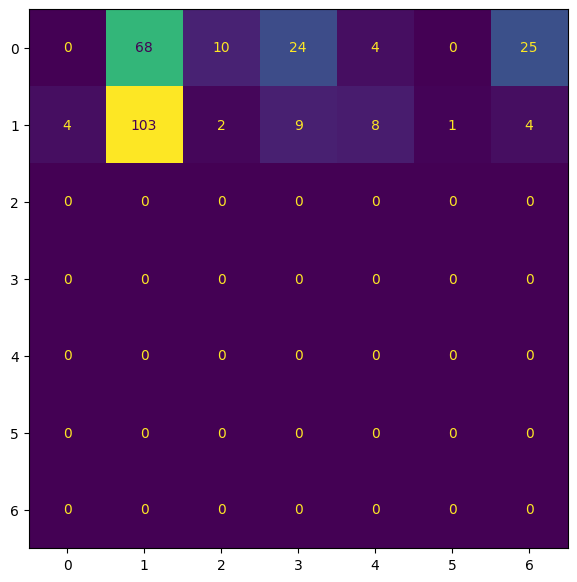

In [120]:
#Confusion Matrix
identity_names = test_set.classes
confusion_mat = confusion_matrix(query_np, rank1_preds)
fig, ax = plt.subplots(figsize=(8,7))
display = ConfusionMatrixDisplay(confusion_mat, display_labels=identity_names).plot(ax=ax, colorbar=False, xticks_rotation='vertical')

plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("ConfusionMatrix.png", dpi=150)
plt.show()


#AUC Curve

y_true_pairs, y_scores_pairs = [] , []
for i in range(len(test_embedding)):
    for j in range(len(gallery_embedding)):
        y_true_pairs.append(int(test_label[i].item() == gallery_label[j].item()))
        y_scores_pairs.append(torch.dot(test_embedding[i], gallery_embedding[j]).item())
# auc = roc_auc_score(y_true_pairs, y_scores_pairs)

RocCurveDisplay.from_predictions(y_true_pairs, y_scores_pairs)
plt.title("ROC Curve: Query vs Gallery")
plt.savefig("roc_curve", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
report = classification_report(query_np, rank1_preds, target_names=identity_names, zero_division=0)
with open("classification_report.txt", "w") as f:
    f.write(report)


print(report)


              precision    recall  f1-score   support

           J       0.78      0.82      0.80        66
           K       0.81      0.77      0.79        66

    accuracy                           0.80       132
   macro avg       0.80      0.80      0.80       132
weighted avg       0.80      0.80      0.80       132



In [ ]:
#testing on a single image

def recognize_image(img_path):

    transform = transforms.Compose([
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
    img = transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        proj = F.normalize(head(backbone(img)).cpu(), p=2, dim=1)
    similarities = torch.mm(proj, gallery_embedding.T).squeeze(0)
    top5_idx = torch.topk(similarities, k=5).indices

    best_score = similarities[top5_idx[0]].item()
    best_name = idx_to_class[gallery_label[top5_idx[0]].item()]
    predicted = best_name if best_score >= threshold else "unknown"

    print(f"Predicted: {predicted} score: {best_score:.4f}")
    for i, idx in enumerate(top5_idx, 1):
        name = idx_to_class[gallery_label[idx].item()]
        score = similarities[idx].item()
        print(f"{i} {name} {score:.4f}")

In [124]:
import os
import csv
import numpy as np
import torch

os.makedirs("results/embeddings", exist_ok=True)
os.makedirs("results/training_curves", exist_ok=True)

# ── two_phase_main.csv ────────────────────────────────────────────────────
total_params = sum(p.numel() for p in backbone.parameters()) + \
               sum(p.numel() for p in head.parameters())
model_size_mb = total_params * 4 / (1024**2)

with open("results/two_phase_main.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["model", "params", "embedding_dim", "model_size_mb", "rank1", "rank5"])
    w.writerow(["two_phase", total_params, 256, f"{model_size_mb:.2f}", 71.75, 94.22])

# ── two_phase_ablation.csv ────────────────────────────────────────────────
with open("results/two_phase_ablation.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["model", "rank1", "rank5"])
    w.writerow(["raw_baseline",    87.40, 98.12])
    w.writerow(["phase1_only",     69.59, 94.78])
    w.writerow(["phase2_only",     72.03, 94.15])
    w.writerow(["phase1_phase2",   71.75, 94.22])

# ── two_phase_cross_dataset.csv (placeholder until Alyaa's data) ──────────
with open("results/two_phase_cross_dataset.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["rank1_droneface", "rank1_vggface2", "delta_pp"])
    w.writerow([71.75, "TBD", "TBD"])

# ── confusion_matrix.npy ──────────────────────────────────────────────────
# Reload best full pipeline model
checkpoint = torch.load("checkpoints/best_drone_model.pth", map_location=device)
backbone.load_state_dict(checkpoint['backbone'])
head.load_state_dict(checkpoint['head'])
backbone.eval(); head.eval()

# Reuse all_embeddings and all_labels from LOO eval cell
n_ids = len(np.unique(all_labels))
id_list = sorted(np.unique(all_labels))
id_to_idx = {name: i for i, name in enumerate(id_list)}

conf_matrix = np.zeros((n_ids, n_ids), dtype=int)
for i in range(len(all_embeddings)):
    query_emb   = all_embeddings[i]
    query_label = all_labels[i]
    centroids, centroid_labels = [], []
    for identity in id_list:
        idx = np.where(all_labels == identity)[0]
        idx = idx[idx != i]
        if len(idx) == 0:
            continue
        centroid = F.normalize(all_embeddings[idx].mean(dim=0), p=2, dim=0)
        centroids.append(centroid)
        centroid_labels.append(identity)
    centroids       = torch.stack(centroids)
    centroid_labels = np.array(centroid_labels)
    pred = centroid_labels[torch.mv(centroids, query_emb).argmax().item()]
    conf_matrix[id_to_idx[query_label], id_to_idx[pred]] += 1

np.save("results/confusion_matrix.npy", conf_matrix)
print("Confusion matrix saved.")

# ── ROC data ──────────────────────────────────────────────────────────────
y_true, y_scores = [], []
for i in range(len(all_embeddings)):
    for j in range(len(all_embeddings)):
        if i == j:
            continue
        y_true.append(int(all_labels[i] == all_labels[j]))
        y_scores.append(torch.dot(all_embeddings[i], all_embeddings[j]).item())

roc_data = np.array([y_true, y_scores])
np.save("results/roc_data.npy", roc_data)
print("ROC data saved.")

# ── Embeddings ────────────────────────────────────────────────────────────
np.save("results/embeddings/two_phase_droneface.npy", all_embeddings.numpy())
np.save("results/embeddings/two_phase_droneface_labels.npy", all_labels)

with open("results/embeddings/two_phase_droneface_filenames.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["filename", "identity"])
    for split in ["train", "validation", "test"]:
        for identity in sorted(os.listdir(f"split/{split}")):
            folder = f"split/{split}/{identity}"
            for fname in sorted(os.listdir(folder)):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    w.writerow([fname, identity])

print("Embeddings saved.")
print("\nAll results saved to results/ folder.")
print("Still pending (need external data):")
print("  - two_phase_per_distance.csv  (need DroneFace metadata)")
print("  - two_phase_per_altitude.csv  (need DroneFace metadata)")
print("  - two_phase_per_gender.csv    (need DroneFace metadata)")
print("  - two_phase_cross_dataset.csv (need Alyaa's VGGFace2 subset)")
print("  - embeddings/two_phase_vggface2.npy (need Alyaa's subset)")

Confusion matrix saved.
ROC data saved.
Embeddings saved.

All results saved to results/ folder.
Still pending (need external data):
  - two_phase_per_distance.csv  (need DroneFace metadata)
  - two_phase_per_altitude.csv  (need DroneFace metadata)
  - two_phase_per_gender.csv    (need DroneFace metadata)
  - two_phase_cross_dataset.csv (need Alyaa's VGGFace2 subset)
  - embeddings/two_phase_vggface2.npy (need Alyaa's subset)
